In [5]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split

# Project path
project_path = r"C:\Users\HP\OneDrive\Desktop\AI Traffic Accident Risk Prediction"

# Dataset path
data_path = os.path.join(
    project_path,
    "data",
    "UK_Accident.csv"
)

# Load dataset
df = pd.read_csv(data_path)

# Remove unnecessary columns
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

if "Accident_Index" in df.columns:
    df.drop(columns=["Accident_Index"], inplace=True)

# Target
target = "Accident_Severity"

# Features
features = [
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Police_Force",
    "Speed_limit",
    "Light_Conditions",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Special_Conditions_at_Site",
    "Carriageway_Hazards",
    "Urban_or_Rural_Area",
    "Did_Police_Officer_Attend_Scene_of_Accident",
    "Year"
]

# Create X and y
X = df[features].copy()
y = df[target].copy()

# Load best model
model_path = os.path.join(
    project_path,
    "models",
    "best_accident_model.pkl"
)

best_model = joblib.load(model_path)

# Load preprocessing pipeline
preprocessor_path = os.path.join(
    project_path,
    "models",
    "preprocessor.pkl"
)

preprocessor = joblib.load(preprocessor_path)

# Use the same train/test split as Notebook 3
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("=" * 60)
print("MODEL EVALUATION SETUP COMPLETED ✅")
print("=" * 60)

print("\nBest model:", type(best_model).__name__)
print("Test samples:", X_test_processed.shape[0])
print("Processed features:", X_test_processed.shape[1])

MODEL EVALUATION SETUP COMPLETED ✅

Best model: RandomForestClassifier
Test samples: 23
Processed features: 24


In [9]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test_processed)

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         2
           3       0.88      0.71      0.79        21

    accuracy                           0.65        23
   macro avg       0.44      0.36      0.39        23
weighted avg       0.81      0.65      0.72        23



CONFUSION MATRIX
[[ 0  2]
 [ 6 15]]


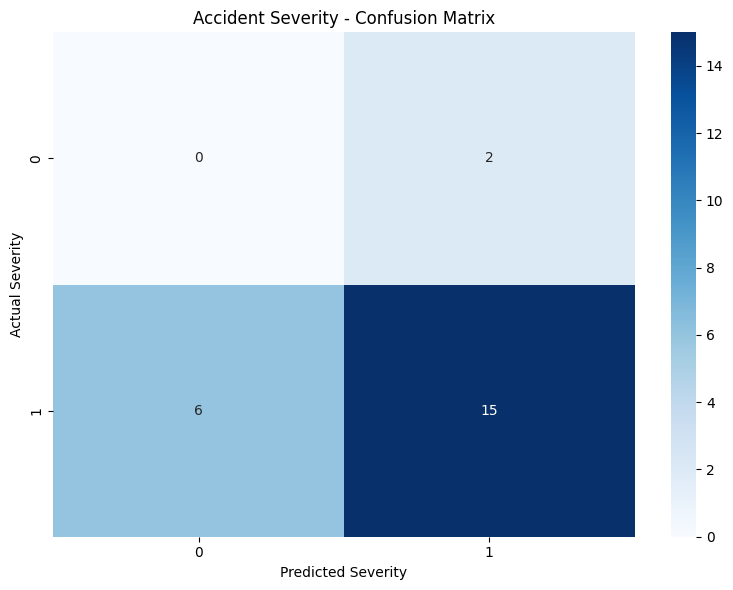

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Accident Severity - Confusion Matrix")
plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

display(evaluation_results)

print("\nPercentage scores:")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

FINAL MODEL PERFORMANCE


,Metric,Score
0,Accuracy,0.652174
1,Precision,0.805627
2,Recall,0.652174
3,F1 Score,0.720824



Percentage scores:
Accuracy : 65.22 %
Precision: 80.56 %
Recall   : 65.22 %
F1 Score : 72.08 %


In [13]:
from sklearn.metrics import roc_auc_score

if hasattr(best_model, "predict_proba"):

    y_probability = best_model.predict_proba(X_test_processed)

    try:
        # Binary classification
        if len(best_model.classes_) == 2:

            positive_probability = y_probability[:, 1]

            roc_auc = roc_auc_score(
                y_test,
                positive_probability
            )

        # Multiclass classification
        else:

            roc_auc = roc_auc_score(
                y_test,
                y_probability,
                multi_class="ovr",
                average="weighted"
            )

        print("=" * 60)
        print("ROC-AUC EVALUATION")
        print("=" * 60)

        print("Weighted ROC-AUC:", round(roc_auc, 4))
        print(
            "ROC-AUC Percentage:",
            round(roc_auc * 100, 2),
            "%"
        )

    except ValueError as error:
        print("ROC-AUC could not be calculated.")
        print("Reason:", error)

else:
    print(
        "The selected model does not support probability prediction."
    )

ROC-AUC EVALUATION
Weighted ROC-AUC: 0.0952
ROC-AUC Percentage: 9.52 %
